<a href="https://colab.research.google.com/github/giuliadesantis/Project_IS_Group43/blob/main/eomt/STEP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

In [ ]:
!git clone https://github.com/giuliadesantis/Project_IS_Group43.git

%cd MaskArchitectureAnomaly_CourseProject/eomt

Cloning into 'Project_IS_Group43'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 147 (delta 30), reused 19 (delta 19), pack-reused 76 (from 2)
Receiving objects: 100% (147/147), 28.13 MiB | 28.38 MiB/s, done.
Resolving deltas: 100% (32/32), done.
[Errno 2] No such file or directory: 'MaskArchitectureAnomaly_CourseProject/eomt'
/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys # Allows importing from the 'eomt' folder
sys.path.append('/content/Project_IS_Group43')
sys.path.append('/content/Project_IS_Group43/eomt')

In [ ]:
!python3 -m pip install -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 21.7 MB/s 

## Setup

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0  # change to the GPU you want to use
IGNORE_INDEX = 255
img_idx = 75  # change to the index of the image you want to visualize
data_path = "/content/drive/MyDrive/CourseProjectAnomaly"  # drive folder of the cityscapes val set

with open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "r") as f:
    config_cs = yaml.safe_load(f)

with open("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml", "r") as f:
    config_coco = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
data_module_name, class_name = config_cs["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config_cs["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)
data.setup()

## Load model

In [ ]:
# flag variable to handle the double configuration
use_coco = False # True if COCO, False if Cityscapes

if use_coco:
    current_config = config_coco
    state_dict_path = "/content/drive/MyDrive/CourseProjectAnomaly/eomt_coco.bin"
    target_img_size = (640, 640)
    num_classes_to_load = 133
else:
    current_config = config_cs
    state_dict_path = "/content/drive/MyDrive/CourseProjectAnomaly/eomt_cityscapes.bin"
    num_classes_to_load = data.num_classes # num classes Cityscapes
    target_img_size = data.img_size

warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = current_config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=target_img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = current_config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=num_classes_to_load,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = current_config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in current_config["model"]["init_args"].items() if k != "network"}

if "stuff_classes" in current_config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = current_config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=target_img_size,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [ ]:
if use_coco:
    target_img_size = (640, 640) # img size Coco
else:
    target_img_size = data.img_size # img size Cityscapes

model_kwargs_final = {k: v for k, v in model_kwargs.items()}

if "num_classes" in model_kwargs_final:
  del model_kwargs_final["num_classes"]

name = current_config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")
is_dinov3 = "dinov3" in name if name else False

if is_dinov3:
    model_kwargs["ckpt_path"] = state_dict_path
    model_kwargs["delta_weights"] = True

model = (
    lit_cls(
        img_size=target_img_size,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs_final,
    )
    .eval()
    .to(device)
)

if not is_dinov3:
    state_dict = torch.load(
        state_dict_path, map_location=f"cuda:{device}", weights_only=True
    )
    model.load_state_dict(state_dict, strict=False)


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

In [ ]:
IGNORE_INDEX = 255

# This dictionary maps category_id of COCO in trainId of Cityscapes (0-18)
coco_to_cityscapes_map = {
    # --- THINGS (Instances) ---
    0: 11,   # person -> person
    1: 18,   # bicycle -> bicycle
    2: 13,   # car -> car
    3: 17,   # motorcycle -> motorcycle
    5: 15,   # bus -> bus
    6: 16,   # train -> train
    7: 14,   # truck -> truck
    9: 6,    # traffic light -> traffic light
    11: 7,   # stop sign -> traffic sign

    # --- STUFF (BackGround/Regions) ---
    100: 0,  # road -> road
    123: 1,  # pavement-merged -> sidewalk
    129: 2,  # building-other-merged -> building
    91: 2,   # house -> building
    131: 3,  # wall-other-merged -> wall
    117: 4,  # fence-merged -> fence
    116: 8,  # tree-merged -> vegetation
    125: 8,  # grass-merged -> vegetation
    90: 9,   # gravel -> terrain
    102: 9,  # sand -> terrain
    119: 10, # sky-other-merged -> sky
}

# function to translate Coco's labels in Cityscapes' label, otherwise ignore index
def translate_preds(pred_array):
    translated = np.full_like(pred_array, fill_value=IGNORE_INDEX)
    for coco_id, city_id in coco_to_cityscapes_map.items():
        translated[pred_array == coco_id] = city_id
    return translated

def infer_semantic(img, target):
    model.eval()

    # Force the model to use the right window dimension
    # (640 for COCO, 1024 for Cityscapes)
    model.window_size = target_img_size[0]

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], target_img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()

    if use_coco: # results if we are in Coco case
        pred_array = translate_preds(pred_array)

    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    img_np = img.permute(1, 2, 0).cpu().numpy()
    if img_np.max() > 1.0 or img_np.min() < 0:
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

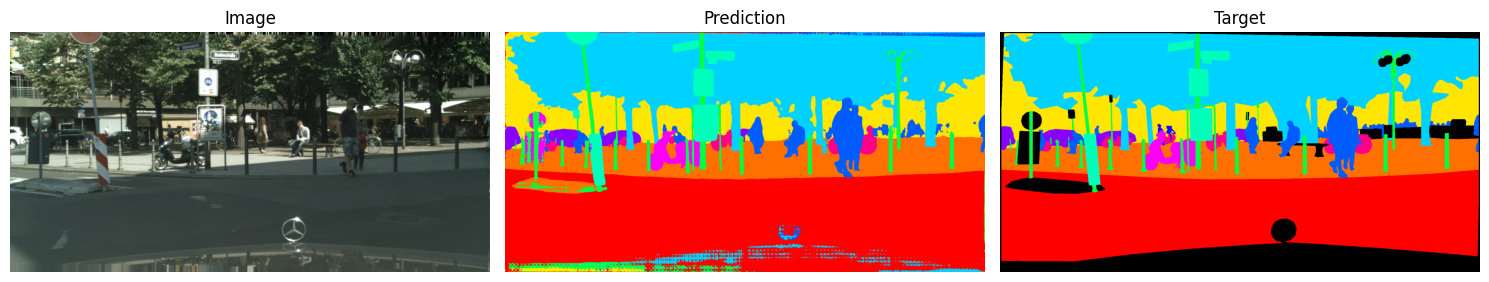

In [ ]:
# run for the cityscapes pre-trained model
img_cs, target_cs = data.val_dataloader().dataset[img_idx]
pred_array_cs, target_array_cs = infer_semantic(img_cs, target_cs)
plot_semantic_results(img_cs, pred_array_cs, target_array_cs)

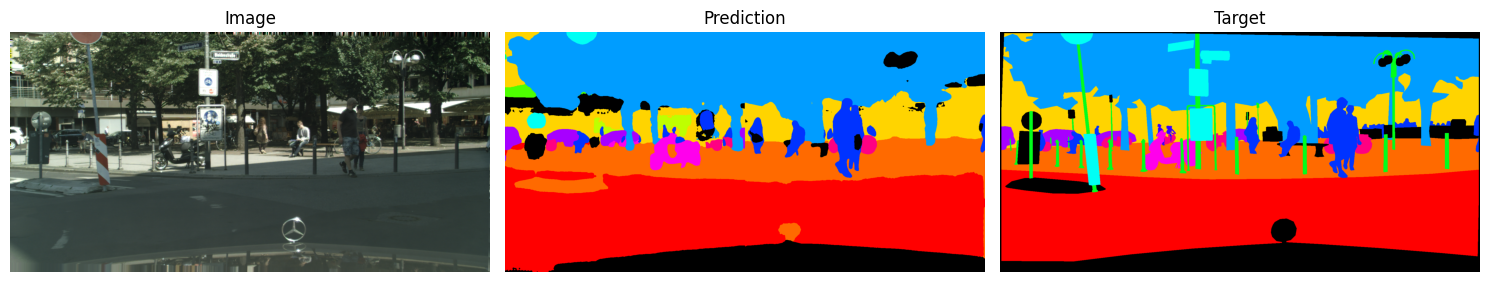

In [ ]:
# run for the coco pre-trained model
img_cc, target_cc = data.val_dataloader().dataset[img_idx]
pred_array_cc, target_array_cc = infer_semantic(img_cc, target_cc)
plot_semantic_results(img_cc, pred_array_cc, target_array_cc)

## Evaluation
Consistent evaluation strategy that allows fair comparison across both models for the semantic segmentation task

In [ ]:
# evaluation on cityscapes
import numpy as np
from tqdm import tqdm

def fast_hist(a, b, n):
    """
    Calcola la matrice di confusione.
    a: ground truth (target), b: predizione, n: numero di classi
    """
    k = (a >= 0) & (a < n) & (b >= 0) & (b < n)
    return np.bincount(n * a[k].astype(int) + b[k], minlength=n**2).reshape(n, n)

def per_class_iu(hist):
    """Calcola la IoU per ogni classe dalla matrice di confusione."""
    return np.diag(hist) / (hist.sum(1) + hist.sum(0) - np.diag(hist))

# setting
num_eval_classes = 19 # Cityscapes classes
hist = np.zeros((num_eval_classes, num_eval_classes))
val_loader = data.val_dataloader()

print(f"evaluation on {len(val_loader)} images...")
print(f"Current model: {'COCO' if use_coco else 'Cityscapes'}")

# evaluation
for i, batch in enumerate(tqdm(val_loader)):
    img = batch[0][0]
    target = batch[1][0]

    pred_array, target_array = infer_semantic(img, target)

    hist += fast_hist(target_array.flatten(), pred_array.flatten(), num_eval_classes)

ious = per_class_iu(hist)
miou = np.nanmean(ious)

# visualization results
classes = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

print("\n" + "="*30)
print(f"Results MIOU - {'COCO' if use_coco else 'CITYSCAPES'}")
print("="*30)
for name, iou in zip(classes, ious):
    print(f"{name:15}: {iou*100:6.2f}%")
print("-" * 30)
print(f"MEAN IoU: {miou*100:6.2f}%")
print("="*30)

evaluation on 500 images...
Current model: Cityscapes


100%|██████████| 500/500 [05:11<00:00,  1.61it/s]


Results MIOU - CITYSCAPES
road           :  98.40%
sidewalk       :  87.36%
building       :  94.15%
wall           :  66.07%
fence          :  65.49%
pole           :  71.04%
traffic light  :  75.00%
traffic sign   :  82.13%
vegetation     :  93.02%
terrain        :  66.60%
sky            :  95.54%
person         :  85.38%
rider          :  71.11%
car            :  95.54%
truck          :  81.79%
bus            :  90.32%
train          :  77.35%
motorcycle     :  74.35%
bicycle        :  81.27%
------------------------------
MEAN IoU:  81.68%


In [ ]:
# eavliation on coco
import numpy as np
from tqdm import tqdm

def fast_hist(a, b, n):
    """
    Calcola la matrice di confusione.
    a: ground truth (target), b: predizione, n: numero di classi
    """
    k = (a >= 0) & (a < n) & (b >= 0) & (b < n)
    return np.bincount(n * a[k].astype(int) + b[k], minlength=n**2).reshape(n, n)

def per_class_iu(hist):
    """Calcola la IoU per ogni classe dalla matrice di confusione."""
    return np.diag(hist) / (hist.sum(1) + hist.sum(0) - np.diag(hist))

# setting
num_eval_classes = 19 # Cityscapes has 19 classes
hist = np.zeros((num_eval_classes, num_eval_classes))
val_loader = data.val_dataloader()

print(f"evaluation on {len(val_loader)} images...")
print(f"Current model: {'COCO' if use_coco else 'Cityscapes'}")

# evaluation
for i, batch in enumerate(tqdm(val_loader)):
    img = batch[0][0]
    target = batch[1][0]

    pred_array, target_array = infer_semantic(img, target)

    hist += fast_hist(target_array.flatten(), pred_array.flatten(), num_eval_classes)

ious = per_class_iu(hist)
miou = np.nanmean(ious)

# visualization results
classes = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

print("\n" + "="*30)
print(f"Results MIOU - {'COCO' if use_coco else 'CITYSCAPES'}")
print("="*30)
for name, iou in zip(classes, ious):
    print(f"{name:15}: {iou*100:6.2f}%")
print("-" * 30)
print(f"MEAN IoU: {miou*100:6.2f}%")
print("="*30)

evaluation on 500 images...
Current model: COCO


100%|██████████| 500/500 [04:31<00:00,  1.84it/s]


Results MIOU - COCO
road           :  94.13%
sidewalk       :  64.84%
building       :  87.72%
wall           :  47.05%
fence          :  49.83%
pole           :   0.00%
traffic light  :  60.64%
traffic sign   :   4.70%
vegetation     :  85.61%
terrain        :   0.44%
sky            :  89.72%
person         :  70.50%
rider          :   0.00%
car            :  84.28%
truck          :  29.35%
bus            :  71.17%
train          :  13.63%
motorcycle     :  63.79%
bicycle        :  73.35%
------------------------------
MEAN IoU:  52.15%


## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

In [ ]:
import os
import zipfile

os.makedirs("/content/coco_dataset", exist_ok=True)

!wget -q -P /content/coco_dataset/ http://images.cocodataset.org/zips/val2017.zip
!wget -q -P /content/coco_dataset/ http://images.cocodataset.org/annotations/panoptic_annotations_trainval2017.zip

with zipfile.ZipFile("/content/coco_dataset/train2017.zip", 'w') as zf:
    pass

In [ ]:
data_path_coco = "/content/coco_dataset"

# Dataloader initialization with config_coco
data_module_name, class_name = config_coco["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config_coco["data"].get("init_args", {})

data_panoptic = data_module(
    path=data_path_coco,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)

data_panoptic.setup(stage="validate")

In [ ]:
def infer_panoptic(img, target):
    model.eval()
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], target_img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        # Convert raw logits into pixel-by-pixel panoptic predictions
        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    try:
      target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
      sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]
    except:
        sem_target = model.to_per_pixel_targets_semantic([target], 255)[0].numpy()
        inst_target = np.zeros_like(sem_target)

    return sem_pred, inst_pred, sem_target, inst_target

In [ ]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

def get_distinct_color(id_val):
    # Generate unique, high-contrast colors
    hue = (id_val * 0.618033988749895) % 1.0
    sat = 0.5 + 0.5 * ((id_val % 3) / 2.0)
    val = 0.6 + 0.4 * ((id_val % 2) / 1.0)
    return mcolors.hsv_to_rgb([hue, sat, val])

def get_aligned_semantic_colors(sem_pred, inst_pred, sem_target, inst_target):
    # Encode categories into a single index to find spatial intersection boundaries
    target_combined = sem_target.astype(np.int64) * 100000 + inst_target.astype(np.int64)
    pred_combined = sem_pred.astype(np.int64) * 100000 + inst_pred.astype(np.int64)
    target_colors = {}
    pred_colors = {}

    for val in np.unique(target_combined):
        s = int(val // 100000)
        if s != 255 and s != -1:
            target_colors[val] = get_distinct_color(s * 7)

    for val in np.unique(pred_combined):
        # Match each prediction color mask to the exact color of its overlapping target
        s = int(val // 100000)
        if s != 255 and s != -1:
            mask = (pred_combined == val)
            overlaps = target_combined[mask]
            valid_overlaps = [v for v in overlaps if (v // 100000) != 255 and (v // 100000) != -1]

            if len(valid_overlaps) > 0:
                u, counts = np.unique(valid_overlaps, return_counts=True)
                best_match = u[np.argmax(counts)]
                pred_colors[val] = target_colors.get(best_match, get_distinct_color(s * 7))
            else:
                pred_colors[val] = get_distinct_color(s * 7)

    return pred_colors, target_colors

def get_aligned_instance_colors(sem_pred, inst_pred, sem_target, inst_target, stuff_classes):
    stuff_set = set([int(x) for x in stuff_classes])
    target_combined = sem_target.astype(np.int64) * 100000 + inst_target.astype(np.int64)
    pred_combined = sem_pred.astype(np.int64) * 100000 + inst_pred.astype(np.int64)
    target_colors = {}
    pred_colors = {}

    # Separate color rules: uniform for 'stuff' background, unique for 'thing' instances
    for val in np.unique(target_combined):
        s = int(val // 100000)
        i = int(val % 100000)
        if s != 255 and s != -1:
            if s in stuff_set or i == 0:
                target_colors[val] = get_distinct_color(s * 7)
            else:
                target_colors[val] = get_distinct_color(val * 11)

    # Find the target segment with maximum overlap to align instance colors identically
    for val in np.unique(pred_combined):
        s = int(val // 100000)
        if s != 255 and s != -1:
            mask = (pred_combined == val)
            overlaps = target_combined[mask]
            valid_overlaps = [v for v in overlaps if (v // 100000) != 255 and (v // 100000) != -1]

            if len(valid_overlaps) > 0:
                u, counts = np.unique(valid_overlaps, return_counts=True)
                best_match = u[np.argmax(counts)]
                pred_colors[val] = target_colors.get(best_match, get_distinct_color(val * 17))
            else:
                pred_colors[val] = get_distinct_color(val * 17)

    return pred_colors, target_colors



def draw_instance_colors(sem, inst, color_map):
  h, w = sem.shape
  out = np.zeros((h, w, 3), dtype=np.float32)
  combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)

  # Apply colors without black boarders
  for val in np.unique(combined):
      mask = (combined == val)
      out[mask] = color_map.get(val, [0.0, 0.0, 0.0])

  return out

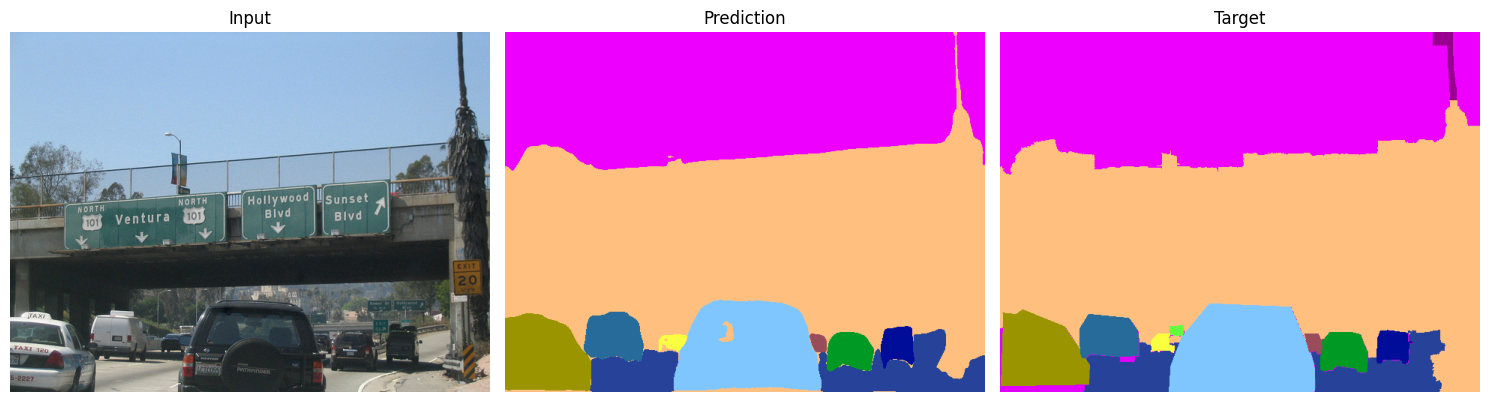

In [ ]:
def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, model_stuff_classes):


    # Generate identical visual configurations for both target and prediction canvas
    pred_colors, target_colors = get_aligned_instance_colors(sem_pred, inst_pred, sem_target, inst_target, model_stuff_classes)
    vis_pred = draw_instance_colors(sem_pred, inst_pred, pred_colors)
    vis_target = draw_instance_colors(sem_target, inst_target, target_colors)

    img_np = img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    if img_np.max() > 1.0 or img_np.min() < 0:
        ptp = img_np.max() - img_np.min()
        if ptp > 0: img_np = (img_np - img_np.min()) / ptp

    # Draw a 3-panel Matplotlib figure containing Input, Prediction, and Ground Truth
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(np.clip(img_np, 0, 1))
    axes[0].set_title("Input")

    axes[1].imshow(np.clip(vis_pred, 0, 1))
    axes[1].set_title(f"Prediction")

    axes[2].imshow(np.clip(vis_target, 0, 1))
    axes[2].set_title(f"Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()



idx_img = 16 #evaluation scene from coco dataset
img_cc_pan, target_cc_pan = data_panoptic.val_dataloader().dataset[idx_img]

# inference
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img_cc_pan, target_cc_pan)
plot_panoptic_results(img_cc_pan, sem_pred, inst_pred, sem_target, inst_target, model.stuff_classes)